# Anomaly Detection in IoT Data — Evaluation

This notebook loads the trained autoencoder, scores unseen sensor windows and visualizes where unusual behavior is detected.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow import keras

ANOMALY_URL = "https://raw.githubusercontent.com/numenta/NAB/master/data/artificialWithAnomaly/art_daily_jumpsup.csv"
MODEL_DIR = Path("../models")

model = keras.models.load_model(MODEL_DIR / "iot_autoencoder.keras")
with open(MODEL_DIR / "scaler.json", encoding="utf-8") as f:
    scaler = json.load(f)
with open(MODEL_DIR / "threshold.json", encoding="utf-8") as f:
    config = json.load(f)

TIME_STEPS = int(scaler["time_steps"])
mean = float(scaler["mean"])
std = float(scaler["std"])
threshold = float(config["threshold"])

In [2]:
test = pd.read_csv(ANOMALY_URL, parse_dates=["timestamp"])
values = test["value"].astype("float32").to_numpy()
scaled = (values - mean) / std

def create_sequences(values, time_steps):
    return np.stack([values[i:i + time_steps] for i in range(len(values) - time_steps + 1)])

x_test = create_sequences(scaled, TIME_STEPS)[..., np.newaxis]
reconstructed = model.predict(x_test, verbose=0)
errors = np.mean(np.abs(reconstructed - x_test), axis=(1, 2))
anomaly_flags = errors > threshold

print("Test windows:", len(x_test))
print("Detected anomalous windows:", int(anomaly_flags.sum()))
print("Threshold:", threshold)

Test windows: 3973
Detected anomalous windows: 223
Threshold: 0.12894293665885925


In [3]:
results = test.iloc[TIME_STEPS - 1:].copy()
results["reconstruction_error"] = errors
results["anomaly"] = anomaly_flags
results.head()

,timestamp,value,reconstruction_error,anomaly
59,2014-04-01 04:55:00,19.298469,0.027269,False
60,2014-04-01 05:00:00,18.731096,0.028037,False
61,2014-04-01 05:05:00,21.583468,0.028961,False
62,2014-04-01 05:10:00,20.977954,0.029589,False
63,2014-04-01 05:15:00,18.422571,0.029320,False


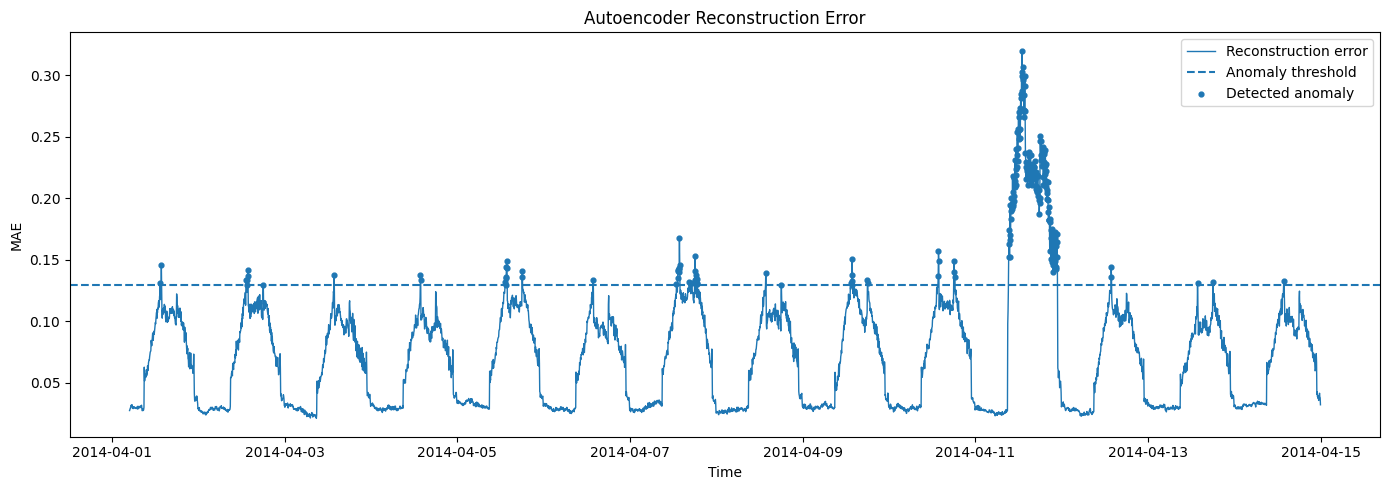

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(results["timestamp"], results["reconstruction_error"], linewidth=1, label="Reconstruction error")
ax.axhline(threshold, linestyle="--", label="Anomaly threshold")
ax.scatter(results.loc[results["anomaly"], "timestamp"], results.loc[results["anomaly"], "reconstruction_error"], s=12, label="Detected anomaly")
ax.set_title("Autoencoder Reconstruction Error")
ax.set_xlabel("Time")
ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
plt.show()

## Interpret the result

The model does not need an explicit anomaly class during training. It learns normal reconstruction behavior and flags windows whose reconstruction error exceeds the threshold. This is useful when real IoT systems have many normal observations but relatively few labeled failures.

In [5]:
print("Highest reconstruction errors:")
display(results.nlargest(10, "reconstruction_error")[["timestamp", "value", "reconstruction_error", "anomaly"]])

Highest reconstruction errors:


,timestamp,value,reconstruction_error,anomaly
3036,2014-04-11 13:00:00,147.562907,0.319810,True
3040,2014-04-11 13:20:00,135.284640,0.306970,True
3035,2014-04-11 12:55:00,153.101670,0.302814,True
3045,2014-04-11 13:45:00,155.783519,0.299167,True
3034,2014-04-11 12:50:00,140.672933,0.299158,True
3039,2014-04-11 13:15:00,152.866135,0.298011,True
3038,2014-04-11 13:10:00,157.611335,0.296141,True
3044,2014-04-11 13:40:00,149.824608,0.291127,True
3037,2014-04-11 13:05:00,161.523165,0.286880,True
3032,2014-04-11 12:40:00,140.595855,0.284498,True
